In [1]:
import numpy as np
import pandas as pd

In [2]:
t04_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.4/fold0_0.4_genomic_windows_table_results.tsv", sep="\t")
t04_fold0["fold"] = [0 for i in range(len(t04_fold0))]
t04_fold0["target"] = [0.4 for i in range(len(t04_fold0))]

In [3]:
t04_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.4/fold1_0.4_genomic_windows_table_results.tsv", sep="\t")
t04_fold1["fold"] = [1 for i in range(len(t04_fold1))]
t04_fold1["target"] = [0.4 for i in range(len(t04_fold1))]

In [4]:
t04_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.4/fold2_0.4_genomic_windows_table_results.tsv", sep="\t")
t04_fold2["fold"] = [2 for i in range(len(t04_fold2))]
t04_fold2["target"] = [0.4 for i in range(len(t04_fold2))]

In [5]:
t06_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.6/fold0_0.6_genomic_windows_table_results.tsv", sep="\t")
t06_fold0["fold"] = [0 for i in range(len(t06_fold0))]
t06_fold0["target"] = [0.6 for i in range(len(t06_fold0))]

In [6]:
t06_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.6/fold1_0.6_genomic_windows_table_results.tsv", sep="\t")
t06_fold1["fold"] = [1 for i in range(len(t06_fold1))]
t06_fold1["target"] = [0.6 for i in range(len(t06_fold1))]

In [7]:
t06_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.6/fold2_0.6_genomic_windows_table_results.tsv", sep="\t")
t06_fold2["fold"] = [2 for i in range(len(t06_fold2))]
t06_fold2["target"] = [0.6 for i in range(len(t06_fold2))]

In [8]:
t08_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.8/fold0_0.8_genomic_windows_table_results.tsv", sep="\t")
t08_fold0["fold"] = [0 for i in range(len(t08_fold0))]
t08_fold0["target"] = [0.8 for i in range(len(t08_fold0))]

In [9]:
t08_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.8/fold1_0.8_genomic_windows_table_results.tsv", sep="\t")
t08_fold1["fold"] = [1 for i in range(len(t08_fold1))]
t08_fold1["target"] = [0.8 for i in range(len(t08_fold1))]

In [10]:
t08_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_0.8/fold2_0.8_genomic_windows_table_results.tsv", sep="\t")
t08_fold2["fold"] = [2 for i in range(len(t08_fold2))]
t08_fold2["target"] = [0.8 for i in range(len(t08_fold2))]

In [11]:
t10_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
t10_fold0["fold"] = [0 for i in range(len(t10_fold0))]
t10_fold0["target"] = [1.0 for i in range(len(t10_fold0))]

In [12]:
t10_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
t10_fold1["fold"] = [1 for i in range(len(t10_fold1))]
t10_fold1["target"] = [1.0 for i in range(len(t10_fold1))]

In [13]:
t10_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_flame/results/target_1.0/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
t10_fold2["fold"] = [2 for i in range(len(t10_fold2))]
t10_fold2["target"] = [1.0 for i in range(len(t10_fold2))]

In [14]:
df = pd.concat([t04_fold0, t04_fold1, t04_fold2,
                t06_fold0, t06_fold1, t06_fold2,
                t08_fold0, t08_fold1, t08_fold2,
                t10_fold0, t10_fold1, t10_fold2], ignore_index=True)

In [16]:
# optimizations with no edits
counts = df.groupby("target")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

target
0.4    34
0.6    30
0.8    28
1.0    27
Name: num_edits, dtype: int64


In [17]:
df = df[df["num_edits"] > 0]

In [18]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'flame_result', 'flame_target', 'flame_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'target'],
      dtype='object')

In [19]:
# optimizations with edits but not sufficent flame score
flame_counts = df.groupby("target")["flame_result"].apply(lambda x: (x <= 0.05).sum())
print(flame_counts)

target
0.4    0
0.6    0
0.8    0
1.0    0
Name: flame_result, dtype: int64


In [20]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("target")["num_edits"].mean()
print(avg_num_edits)

target
0.4    26.292308
0.6    35.634328
0.8    46.080882
1.0    57.291971
Name: num_edits, dtype: float64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
natural_results_path = "/scratch1/smaruj/stripenn_out/selected_stripes_strength_results_median_q3_mean.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")
nat_df = nat_df[nat_df["flame_strength_mean"] > 0.0]

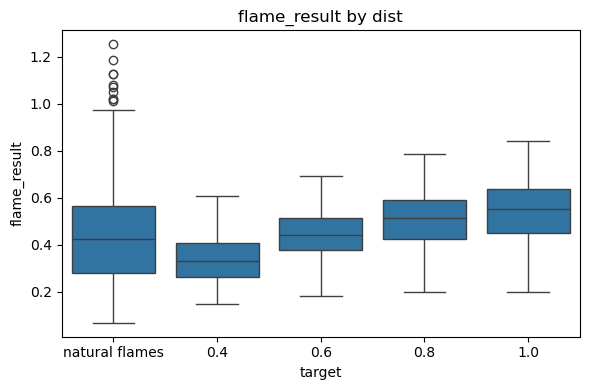

In [27]:
nat_df_box = pd.DataFrame({
    "target": ["natural flames"] * len(nat_df),
    "flame_result": nat_df["flame_strength_q3"]
})

plot_df = pd.concat([
    df[["target", "flame_result"]],
    nat_df_box
], ignore_index=True)

order = ["natural flames"] + sorted(df["target"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=plot_df, x="target", y="flame_result", order=order)

plt.xlabel("target")
plt.ylabel("flame_result")
plt.title("flame_result by dist")
plt.tight_layout()
plt.show()

In [28]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'flame_result', 'flame_target', 'flame_init', 'num_edits', 'GC_seq',
       'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'target'],
      dtype='object')

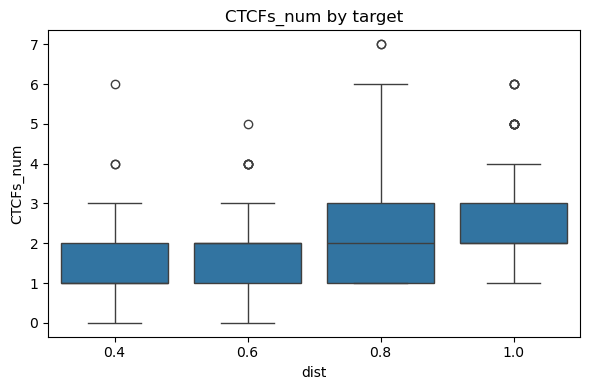

In [30]:
order = sorted(df["target"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="target", y="CTCFs_num", order=order)
plt.xlabel("dist")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by target")
plt.tight_layout()
plt.show()

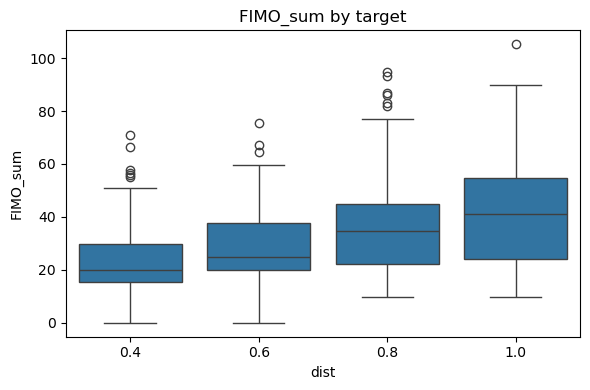

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="target", y="FIMO_sum", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by target")
plt.tight_layout()
plt.show()

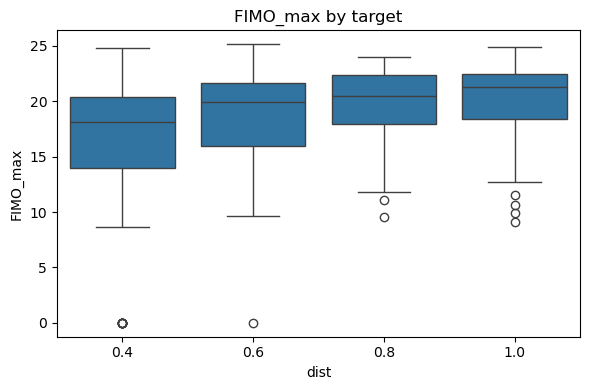

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="target", y="FIMO_max", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by target")
plt.tight_layout()
plt.show()

In [33]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [34]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

/tmp/SLURM_1690852/ipykernel_3500651/1416642963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["orientation_canonical"] = df["orientation"].apply(canonicalize)


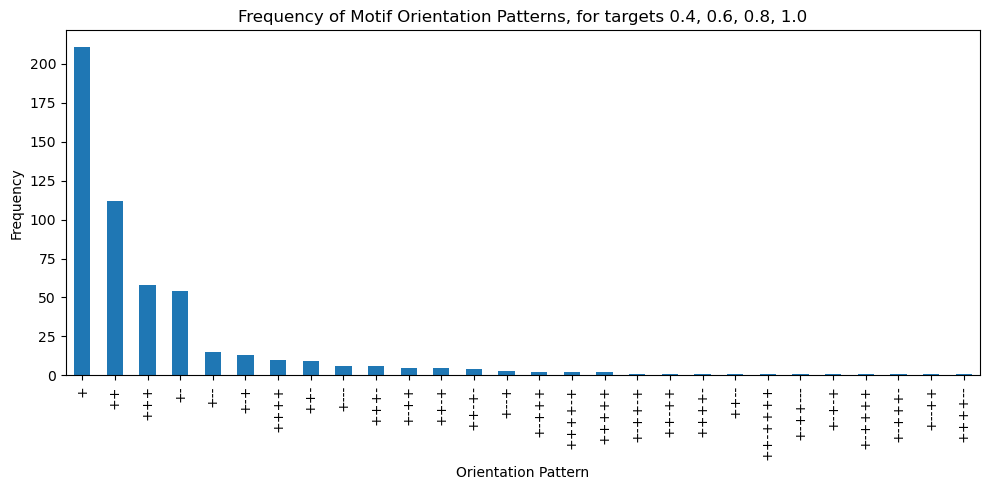

In [36]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for targets 0.4, 0.6, 0.8, 1.0")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()